In [5]:
pip install nibabel matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# 1.Data Visulisation

In [6]:
import zipfile
import os

# extracting the zip files to check out the dataset
training_zip = 'Dataset/TrainingData.zip'
test_zip = 'Dataset/TestData.zip'

# creating folder for report images
os.makedirs('report_images/data_understanding', exist_ok=True)

# unzipping training data
if os.path.exists(training_zip):
    with zipfile.ZipFile(training_zip, 'r') as zip_ref:
        # they are extracted in a folder called Extracted_Data
        zip_ref.extractall('Dataset/Extracted_Data')
    print("Training Data unzipped successfully!")
else:
    print(f" can't find the file at: {training_zip}")

#  Unzipping Test Data
if os.path.exists(test_zip):
    with zipfile.ZipFile(test_zip, 'r') as zip_ref:
        zip_ref.extractall('Dataset/Extracted_Data')
    print("Test Data unzipped successfully!")
else:
    print(f" can't find the file at: {test_zip}")

Training Data unzipped successfully!
Test Data unzipped successfully!


T1 shape: (240, 240, 48)
Label shape: (240, 240, 48)
T1 min intensity: -22.0
T1 max intensity: 701.0
Unique label values: [0. 1. 2. 3. 4. 5. 6. 7. 8.]


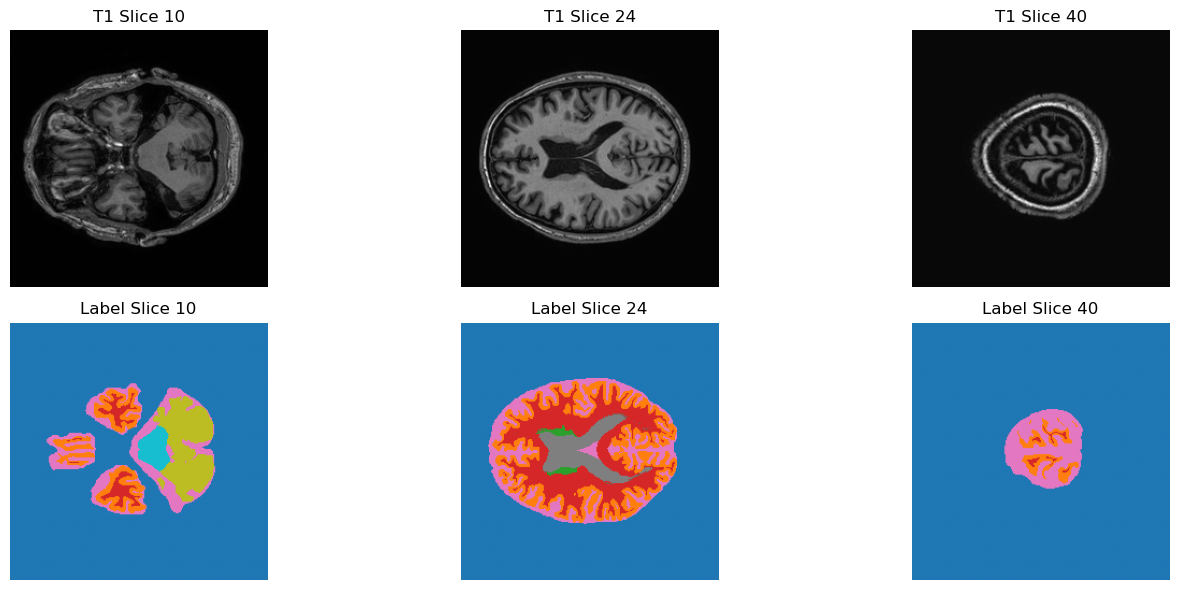

In [7]:
import nibabel as nib
import matplotlib.pyplot as plt
import os
import numpy as np

base_path = 'Dataset/Extracted_Data/TrainingData/1/'
t1_path = os.path.join(base_path, 'T1.nii')
label_path = os.path.join(base_path, 'LabelsForTraining.nii')

# Loading data
t1_data = nib.load(t1_path).get_fdata()
label_data = nib.load(label_path).get_fdata()

# printing basic information about the data
print("T1 shape:", t1_data.shape)
print("Label shape:", label_data.shape)
print("T1 min intensity:", np.min(t1_data))
print("T1 max intensity:", np.max(t1_data))
print("Unique label values:", np.unique(label_data))


slice_indices = [10, 24, 40]

plt.figure(figsize=(15, 6))

for i, slice_idx in enumerate(slice_indices):

    #  the MRI Scan
    plt.subplot(2, len(slice_indices), i + 1)
    plt.imshow(t1_data[:, :, slice_idx], cmap='gray')
    plt.title(f"T1 Slice {slice_idx}")
    plt.axis('off')

    plt.subplot(2, len(slice_indices), i + 1 + len(slice_indices))
    plt.imshow(label_data[:, :, slice_idx], cmap='tab10', vmin=0, vmax=8)
    plt.title(f"Label Slice {slice_idx}")
    plt.axis('off')

plt.tight_layout()

# saving the figure
save_path = os.path.join('report_images/data_understanding', 'Subject1_MultiSlice.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

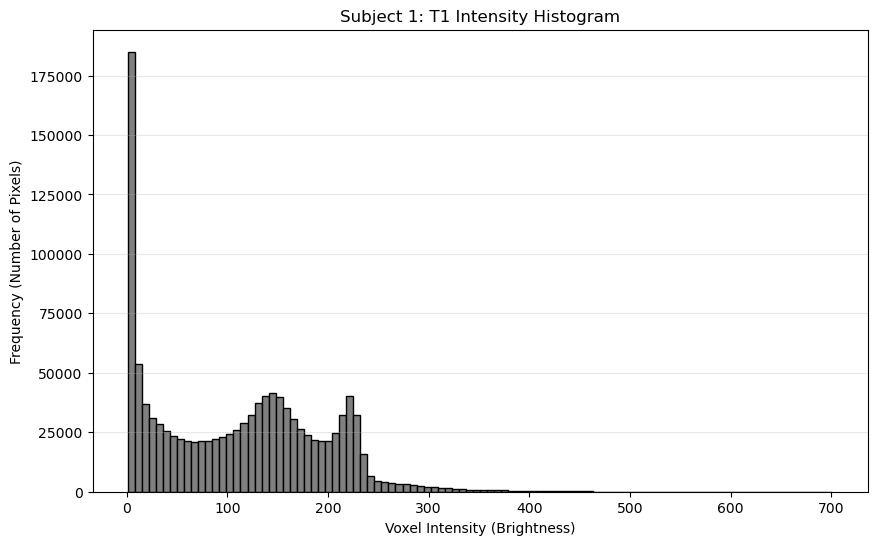

In [8]:

# We ignore 0 the black background to see the brain better
# checking the intensity vakue of one subject
# 1. Prepare data
brain_pixels = t1_data[t1_data > 0].flatten()
folder_name = 'report_images'

# 2.  plotting
plt.figure(figsize=(10, 6))
plt.hist(brain_pixels, bins=100, color='gray', edgecolor='black')
plt.title("Subject 1: T1 Intensity Histogram")
plt.xlabel("Voxel Intensity (Brightness)")
plt.ylabel("Frequency (Number of Pixels)")
plt.grid(axis='y', alpha=0.3)

save_path = os.path.join(folder_name, 'Subject1_T1_Histogram.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight') 

plt.show() 


Class 0: 2261444 voxels
Class 1: 155930 voxels
Class 2: 11943 voxels
Class 3: 123979 voxels
Class 4: 605 voxels
Class 5: 150374 voxels
Class 6: 13701 voxels
Class 7: 39065 voxels
Class 8: 7759 voxels


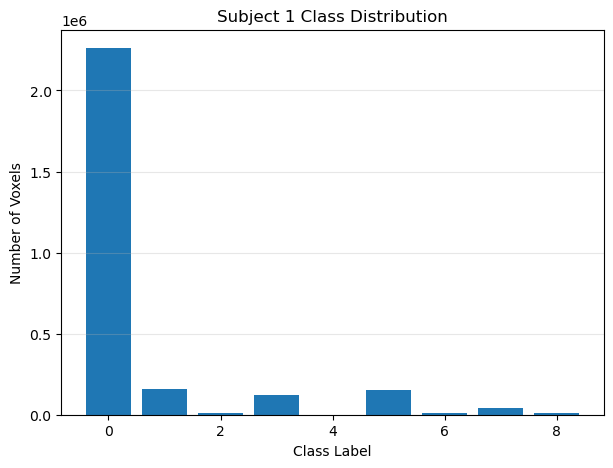

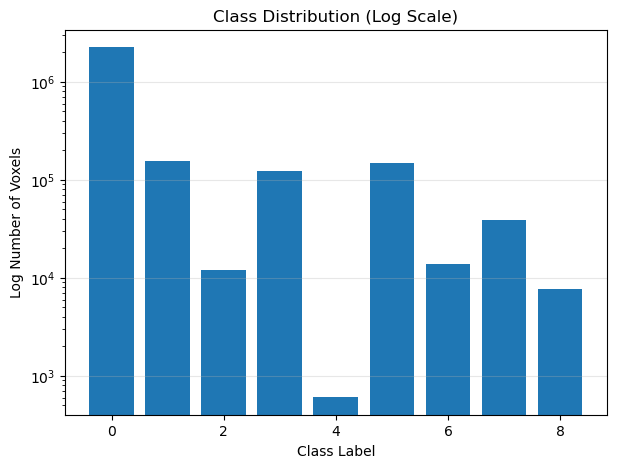

In [9]:

# counting number of voxels per class
unique, counts = np.unique(label_data, return_counts=True)

for u, c in zip(unique, counts):
    print(f"Class {int(u)}: {c} voxels")

# plotting class distribution
plt.figure(figsize=(7, 5))
plt.bar(unique.astype(int), counts)
plt.title("Subject 1 Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Voxels")
plt.grid(axis='y', alpha=0.3)

# saving the plot
plt.savefig('report_images/data_understanding/Subject1_Class_Distribution.png',
            dpi=300, bbox_inches='tight')

plt.show()

 # a zoomed in version to get a better look 

plt.figure(figsize=(7, 5))
plt.bar(unique.astype(int), counts)
plt.yscale('log')
plt.title("Class Distribution (Log Scale)")
plt.xlabel("Class Label")
plt.ylabel("Log Number of Voxels")
plt.grid(axis='y', alpha=0.3)

plt.savefig('report_images/data_understanding/Subject1_Class_Distribution_Log.png',
            dpi=300, bbox_inches='tight')

plt.show()

In [10]:
# calculating stats to get the the idea about distribution of each subject 

for i in range(1, 6):
    path = f'Dataset/Extracted_Data/TrainingData/{i}/T1.nii'
    
    if os.path.exists(path):
        data = nib.load(path).get_fdata()
        pixels = data[data > 0]
        
        print(
            f"Subject {i}: "
            f"Mean={pixels.mean():.2f}, "
            f"Std={pixels.std():.2f}, "
            f"Min={pixels.min():.2f}, "
            f"Max={pixels.max():.2f}"
        )

Subject 1: Mean=109.70, Std=83.69, Min=1.00, Max=701.00
Subject 2: Mean=101.14, Std=81.02, Min=1.00, Max=508.00
Subject 3: Mean=128.79, Std=100.97, Min=1.00, Max=746.00
Subject 4: Mean=116.11, Std=93.30, Min=1.00, Max=610.00
Subject 5: Mean=114.32, Std=89.40, Min=1.00, Max=625.00


/tmp/ipykernel_136/741900953.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_pixels, labels=[f"S{i}" for i in range(1, 6)])


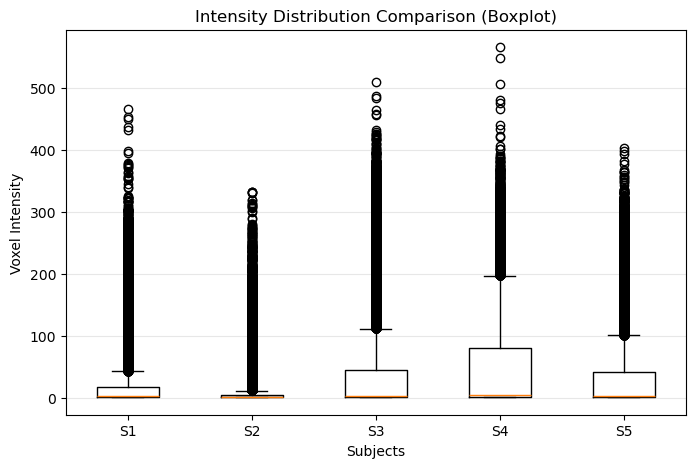

In [11]:


# collecting pixel values for all subjects
all_pixels = []

for i in range(1, 6):
    path = f'Dataset/Extracted_Data/TrainingData/{i}/T1.nii'
    
    if os.path.exists(path):
        data = nib.load(path).get_fdata()
        pixels = data[data > 0].flatten()
        
        # sampling for faster plotting
        pixels = pixels[:50000]
        
        all_pixels.append(pixels)

# plotting boxplot
plt.figure(figsize=(8, 5))
plt.boxplot(all_pixels, labels=[f"S{i}" for i in range(1, 6)])

plt.title("Intensity Distribution Comparison (Boxplot)")
plt.xlabel("Subjects")
plt.ylabel("Voxel Intensity")
plt.grid(axis='y', alpha=0.3)

# saving
plt.savefig('report_images/data_understanding/Intensity_Boxplot.png',
            dpi=300, bbox_inches='tight')

plt.show()

# 2.Data preprocessing

In [12]:
def normalize_volume(volume):
    """
    Normalize MRI volume using z-score normalization.
    Mean and std are calculated only from non-background voxels.Otherwise the mean will be biased by 0's due to large no of 0 valued pixels.
    """
    brain_pixels = volume[volume > 0]

    mean = brain_pixels.mean()
    std = brain_pixels.std()

    normalized_volume = (volume - mean) / (std + 1e-8)

    return normalized_volume

In [13]:
normalized_t1 = normalize_volume(t1_data)

print("Before normalization:")
print("Mean:", t1_data[t1_data > 0].mean())
print("Std:", t1_data[t1_data > 0].std())

print("\nAfter normalization:")
print("Mean:", normalized_t1[t1_data > 0].mean())
print("Std:", normalized_t1[t1_data > 0].std())

Before normalization:
Mean: 109.70128618099464
Std: 83.6908097098705

After normalization:
Mean: -8.791240504748146e-17
Std: 0.9999999998805129


In [20]:

def extract_patch(volume, label, patch_size=(64, 64, 32)):
    """
    Extract one random 3D patch from the MRI volume and label.
    """

    x_size, y_size, z_size = volume.shape
    px, py, pz = patch_size

    # randomly choosing starting point
    x_start = np.random.randint(0, x_size - px + 1)
    y_start = np.random.randint(0, y_size - py + 1)
    z_start = np.random.randint(0, z_size - pz + 1)

    # extracting image patch
    image_patch = volume[
        x_start:x_start + px,
        y_start:y_start + py,
        z_start:z_start + pz
    ]

    # extracting label patch
    label_patch = label[
        x_start:x_start + px,
        y_start:y_start + py,
        z_start:z_start + pz
    ]

    return image_patch, label_patch

In [23]:
normalized_t1 = normalize_volume(t1_data)

image_patch, label_patch = extract_patch(
    normalized_t1,
    label_data,
    patch_size=(64, 64, 32)
)

print("Image patch shape:", image_patch.shape)
print("Label patch shape:", label_patch.shape)
print("Unique labels in patch:", np.unique(label_patch))

Image patch shape: (64, 64, 32)
Label patch shape: (64, 64, 32)
Unique labels in patch: [0. 1. 3. 5. 7.]


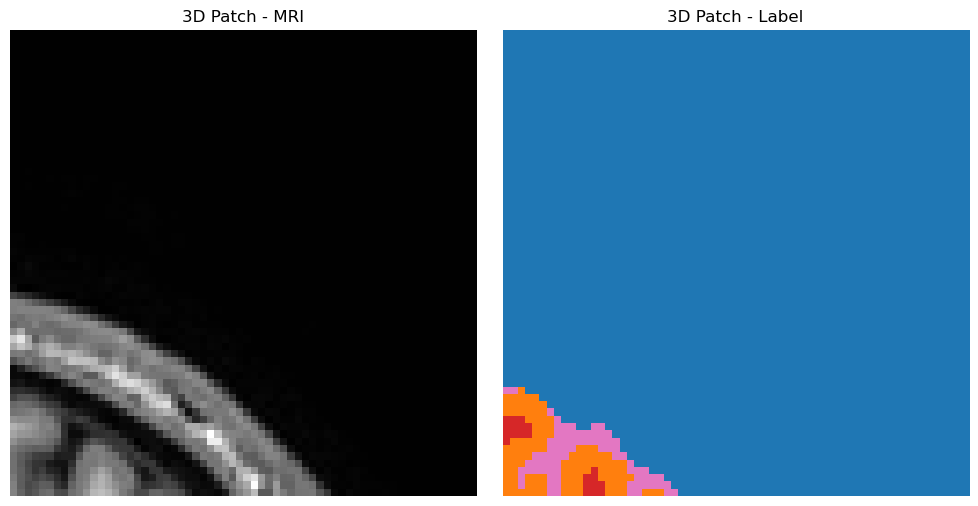

In [24]:
slice_idx = image_patch.shape[2] // 2

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_patch[:, :, slice_idx], cmap='gray')
plt.title("3D Patch - MRI")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(label_patch[:, :, slice_idx], cmap='tab10', vmin=0, vmax=8)
plt.title("3D Patch - Label")
plt.axis('off')

plt.tight_layout()
plt.savefig("report_images/data_understanding/random_3d_patch.png",
            dpi=300, bbox_inches='tight')
plt.show()

In [12]:
def extract_patch_foreground_aware(
    volume,
    label,
    patch_size=(96, 96, 32),
    foreground_prob=0.7
):
    """
    Extract a 3D patch using foreground-aware sampling.

    With probability foreground_prob, the patch is centred around
    a randomly selected foreground voxel where label > 0.

    Otherwise, a fully random patch is extracted.
    """

    x_size, y_size, z_size = volume.shape
    px, py, pz = patch_size

    use_foreground = np.random.rand() < foreground_prob
    foreground_voxels = np.argwhere(label > 0)

    if use_foreground and len(foreground_voxels) > 0:
        center_x, center_y, center_z = foreground_voxels[
            np.random.randint(len(foreground_voxels))
        ]

        x_start = center_x - px // 2
        y_start = center_y - py // 2
        z_start = center_z - pz // 2

        x_start = np.clip(x_start, 0, x_size - px)
        y_start = np.clip(y_start, 0, y_size - py)
        z_start = np.clip(z_start, 0, z_size - pz)

    else:
        x_start = np.random.randint(0, x_size - px + 1)
        y_start = np.random.randint(0, y_size - py + 1)
        z_start = np.random.randint(0, z_size - pz + 1)

    image_patch = volume[
        x_start:x_start + px,
        y_start:y_start + py,
        z_start:z_start + pz
    ]

    label_patch = label[
        x_start:x_start + px,
        y_start:y_start + py,
        z_start:z_start + pz
    ]

    return image_patch, label_patch

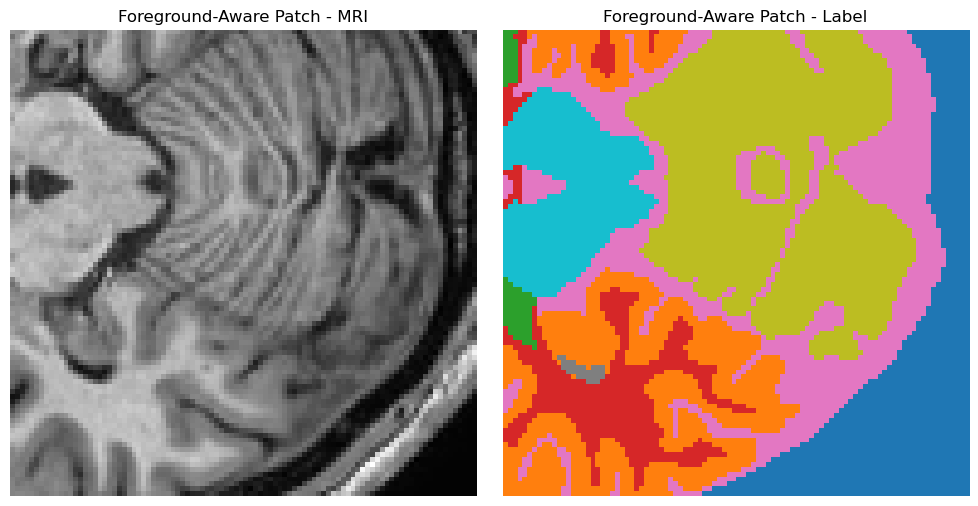

Unique labels in foreground-aware patch: [0 1 2 3 4 5 6 7 8]


In [13]:
# Create one foreground-aware patch for visual inspection
image_patch_fg, label_patch_fg = extract_patch_foreground_aware(
    normalized_t1,
    label_data.astype(np.int64),
    patch_size=(96, 96, 32),
    foreground_prob=1.0   # force foreground-aware sampling for visualisation
)

# Choose middle slice of patch
slice_idx = image_patch_fg.shape[2] // 2

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_patch_fg[:, :, slice_idx], cmap='gray')
plt.title("Foreground-Aware Patch - MRI")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(label_patch_fg[:, :, slice_idx], cmap='tab10', vmin=0, vmax=8)
plt.title("Foreground-Aware Patch - Label")
plt.axis('off')

plt.tight_layout()

plt.savefig(
    "report_images/data_understanding/foreground_aware_3d_patch.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Unique labels in foreground-aware patch:", np.unique(label_patch_fg))

In [14]:
def extract_patch_class_aware(
    volume,
    label,
    patch_size=(96, 96, 32),
    target_class=4,
    class_prob=0.4,
    foreground_prob=0.3
):
    """
    Extract a 3D patch using class-aware sampling.

    Sampling logic:
    - With probability class_prob, centre patch around target_class voxel.
    - Else with probability foreground_prob, centre patch around any foreground voxel.
    - Otherwise use random patch.
    """

    x_size, y_size, z_size = volume.shape
    px, py, pz = patch_size

    r = np.random.rand()

    target_voxels = np.argwhere(label == target_class)
    foreground_voxels = np.argwhere(label > 0)

    if r < class_prob and len(target_voxels) > 0:
        center_x, center_y, center_z = target_voxels[
            np.random.randint(len(target_voxels))
        ]

    elif r < class_prob + foreground_prob and len(foreground_voxels) > 0:
        center_x, center_y, center_z = foreground_voxels[
            np.random.randint(len(foreground_voxels))
        ]

    else:
        x_start = np.random.randint(0, x_size - px + 1)
        y_start = np.random.randint(0, y_size - py + 1)
        z_start = np.random.randint(0, z_size - pz + 1)

        image_patch = volume[
            x_start:x_start + px,
            y_start:y_start + py,
            z_start:z_start + pz
        ]

        label_patch = label[
            x_start:x_start + px,
            y_start:y_start + py,
            z_start:z_start + pz
        ]

        return image_patch, label_patch

    x_start = center_x - px // 2
    y_start = center_y - py // 2
    z_start = center_z - pz // 2

    x_start = np.clip(x_start, 0, x_size - px)
    y_start = np.clip(y_start, 0, y_size - py)
    z_start = np.clip(z_start, 0, z_size - pz)

    image_patch = volume[
        x_start:x_start + px,
        y_start:y_start + py,
        z_start:z_start + pz
    ]

    label_patch = label[
        x_start:x_start + px,
        y_start:y_start + py,
        z_start:z_start + pz
    ]

    return image_patch, label_patch

## Dataset and Data loader

In [40]:
import scipy.ndimage as ndimage
import numpy as np

def elastic_deformation(image, label, alpha=10, sigma=2):
    """
    Apply smooth elastic deformation to 3D image and label.

    alpha:
        deformation strength

    sigma:
        smoothness of deformation
    """

    shape = image.shape

    dx = ndimage.gaussian_filter(
        (np.random.rand(*shape) * 2 - 1),
        sigma,
        mode="constant",
        cval=0
    ) * alpha

    dy = ndimage.gaussian_filter(
        (np.random.rand(*shape) * 2 - 1),
        sigma,
        mode="constant",
        cval=0
    ) * alpha

    dz = ndimage.gaussian_filter(
        (np.random.rand(*shape) * 2 - 1),
        sigma,
        mode="constant",
        cval=0
    ) * alpha

    x, y, z = np.meshgrid(
        np.arange(shape[0]),
        np.arange(shape[1]),
        np.arange(shape[2]),
        indexing='ij'
    )

    indices = (
        x + dx,
        y + dy,
        z + dz
    )

    deformed_image = ndimage.map_coordinates(
        image,
        indices,
        order=1,
        mode='reflect'
    )

    deformed_label = ndimage.map_coordinates(
        label,
        indices,
        order=0,
        mode='reflect'
    )

    return deformed_image, deformed_label

In [41]:
def apply_augmentations(patch, label):

    # Random flips
    for axis in range(3):
        if np.random.rand() < 0.5:
            patch = np.flip(patch, axis=axis).copy()
            label = np.flip(label, axis=axis).copy()

    # Elastic deformation
    if np.random.rand() < 0.3:
        patch, label = elastic_deformation(
            patch,
            label,
            alpha=10,
            sigma=2
        )

    # Random intensity scaling
    if np.random.rand() < 0.3:
        scale = np.random.uniform(0.9, 1.1)
        patch = patch * scale

    # Random intensity shift
    if np.random.rand() < 0.3:
        shift = np.random.uniform(-0.1, 0.1)
        patch = patch + shift

    # Gaussian noise
    if np.random.rand() < 0.2:
        noise = np.random.normal(0, 0.01, patch.shape)
        patch = patch + noise

    return patch.astype(np.float32), label.astype(np.int64)

In [42]:
import torch
from torch.utils.data import Dataset, DataLoader

class MRIDataset(Dataset):
    def __init__(
        self,
        data_path,
        subjects=None,
        patch_size=(64, 64, 32),
        patches_per_epoch=100,
        foreground_aware=False,
        foreground_prob=0.7,
        class_aware=False,
        target_class=4,
        class_prob=0.4,
        augment=False
    ):
        self.data_path = data_path
        self.patch_size = patch_size
        self.subjects = subjects if subjects is not None else [str(i) for i in range(1, 6)]
        self.patches_per_epoch = patches_per_epoch
        self.foreground_aware = foreground_aware
        self.foreground_prob = foreground_prob
        self.class_aware = class_aware
        self.target_class = target_class
        self.class_prob = class_prob
        self.augment = augment

        self.volumes = {}
        self.labels = {}

        for subject_id in self.subjects:
            base_path = os.path.join(self.data_path, subject_id)

            volume = nib.load(os.path.join(base_path, "T1.nii")).get_fdata()
            label = nib.load(os.path.join(base_path, "LabelsForTraining.nii")).get_fdata()

            self.volumes[subject_id] = normalize_volume(volume)
            self.labels[subject_id] = label.astype(np.int64)

    def __len__(self):
        return self.patches_per_epoch

    def __getitem__(self, idx):
        subject_id = np.random.choice(self.subjects)

        volume = self.volumes[subject_id]
        label = self.labels[subject_id]

        if self.class_aware:
            image_patch, label_patch = extract_patch_class_aware(
                volume,
                label,
                patch_size=self.patch_size,
                target_class=self.target_class,
                class_prob=self.class_prob,
                foreground_prob=self.foreground_prob
            )

        elif self.foreground_aware:
            image_patch, label_patch = extract_patch_foreground_aware(
                volume,
                label,
                patch_size=self.patch_size,
                foreground_prob=self.foreground_prob
            )

        else:
            image_patch, label_patch = extract_patch(
                volume,
                label,
                patch_size=self.patch_size
            )

        if self.augment:
            image_patch, label_patch = apply_augmentations(
                image_patch,
                label_patch
            )

        image_patch = torch.tensor(image_patch, dtype=torch.float32).unsqueeze(0)
        label_patch = torch.tensor(label_patch, dtype=torch.long)

        return image_patch, label_patch

In [43]:
train_data_path = 'Dataset/Extracted_Data/TrainingData'

train_dataset = MRIDataset(
    data_path=train_data_path,
    patch_size=(64, 64, 32)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True
)

print("Number of subjects in dataset:", len(train_dataset))

Number of subjects in dataset: 100


In [44]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("Image min:", images.min().item())
print("Image max:", images.max().item())

print("Unique labels in batch:", torch.unique(labels))

Image batch shape: torch.Size([1, 1, 64, 64, 32])
Label batch shape: torch.Size([1, 64, 64, 32])
Image dtype: torch.float32
Label dtype: torch.int64
Image min: -1.4088915586471558
Image max: 4.70094108581543
Unique labels in batch: tensor([0, 1, 2, 3, 4, 5, 6, 8])


#    3. 3D U-Net model

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [66]:

"""
class ConvBlock3D(nn.Module):
   
   # 3D convolution block: Conv3d -> BatchNorm3d -> ReLU
   
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)
"""
        
class ConvBlock3D(nn.Module):

   # 3D convolution block: Conv3d -> InstanceNorm3d -> LeakyReLU

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            # Replacing BatchNorm3d with InstanceNorm3d because we are using the batch size =1 so their is no purpose of using batch normalisation
            nn.InstanceNorm3d(out_channels, affine=True), 
            # Switching to LeakyReLU as suggested by nnU-Net
            nn.LeakyReLU(negative_slope=1e-2, inplace=True),
            
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.InstanceNorm3d(out_channels, affine=True),
            nn.LeakyReLU(negative_slope=1e-2, inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [67]:
class Encoder3D(nn.Module):
    def __init__(self, in_channels, feature_sizes=[32, 64, 128]):
        super().__init__()
        self.layers = nn.ModuleList()
        prev_ch = in_channels
        for fs in feature_sizes:
            self.layers.append(ConvBlock3D(prev_ch, fs))
            prev_ch = fs
        self.pool = nn.MaxPool3d(2)

    def forward(self, x):
        features = []
        for layer in self.layers:
            x = layer(x)
            features.append(x)
            x = self.pool(x)
        return features

In [68]:

class Decoder3D(nn.Module):
    def __init__(self, feature_sizes=[128, 64, 32], n_classes=9):
       
        super().__init__()
        self.up_convs = nn.ModuleList()
        self.conv_blocks = nn.ModuleList()
        
        for idx in range(len(feature_sizes)-1):
            # First upconv takes bottleneck output 
            if idx == 0:
                in_ch = feature_sizes[0]*2  # bottleneck output
            else:
                in_ch = feature_sizes[idx]
            out_ch = feature_sizes[idx+1]
            
            self.up_convs.append(
                nn.ConvTranspose3d(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    kernel_size=2,
                    stride=2
                )
            )
            
            # After concatenation with encoder features
            self.conv_blocks.append(
                ConvBlock3D(in_channels=out_ch*2, out_channels=out_ch)
            )
        
        self.final_conv = nn.Conv3d(feature_sizes[-1], n_classes, kernel_size=1)

    def forward(self, x, enc_features):
        for idx in range(len(self.up_convs)):
            x = self.up_convs[idx](x)
            
            # getting corresponding encoder feature map
            enc_feat = enc_features[-(idx+2)]
            
            # padding if sizes mismatch
            if x.shape != enc_feat.shape:
                diffZ = enc_feat.size(2) - x.size(2)
                diffY = enc_feat.size(3) - x.size(3)
                diffX = enc_feat.size(4) - x.size(4)
                
                x = F.pad(x, [
                    diffX // 2, diffX - diffX // 2,
                    diffY // 2, diffY - diffY // 2,
                    diffZ // 2, diffZ - diffZ // 2
                ])
            
            # concatenate encoder features
            x = torch.cat([x, enc_feat], dim=1)
            
            # conv block
            x = self.conv_blocks[idx](x)
        
        # final output
        x = self.final_conv(x)
        return x

In [69]:
class UNet3D(nn.Module):
    def __init__(self, in_channels=1, n_classes=9, feature_sizes=[32, 64, 128]):
        super().__init__()
        self.encoder = Encoder3D(in_channels, feature_sizes)
        self.bottleneck = ConvBlock3D(feature_sizes[-1], feature_sizes[-1]*2)
        self.decoder = Decoder3D(feature_sizes[::-1], n_classes)

    def forward(self, x):
        enc_features = self.encoder(x)
        bottleneck = self.bottleneck(enc_features[-1])
        out = self.decoder(bottleneck, enc_features)
        return out

In [70]:
class DiceLoss(nn.Module):
    """
    Multi-class Dice Loss
    """
    def __init__(self, smooth=1e-5):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, true):
        """
        logits: [B, C, H, W, D]
        true: [B, H, W, D] with class indices
        """
        num_classes = logits.shape[1]

        true_onehot = F.one_hot(true, num_classes=num_classes) \
                        .permute(0, 4, 1, 2, 3) \
                        .float()

        probs = F.softmax(logits, dim=1)

        dims = (0, 2, 3, 4)  # sum over batch + spatial dims

        intersection = torch.sum(probs * true_onehot, dims)
        cardinality = torch.sum(probs + true_onehot, dims)

        dice = (2. * intersection + self.smooth) / (cardinality + self.smooth)

        return 1 - dice.mean()

In [71]:
class DiceCELoss(nn.Module):
    """
    Combination of Dice Loss + CrossEntropy Loss
    """
    def __init__(self, dice_weight=1.0, ce_weight=3.0):
        super().__init__()
        self.dice = DiceLoss()
        self.ce = nn.CrossEntropyLoss()
        self.dice_weight = dice_weight
        self.ce_weight = ce_weight

    def forward(self, logits, targets):
        """
        logits: [B, C, H, W, D]
        targets: [B, H, W, D]
        """
        dice_loss = self.dice(logits, targets)
        ce_loss = self.ce(logits, targets)

        return self.dice_weight * dice_loss + self.ce_weight * ce_loss

In [72]:
class DiceCEWeightedLoss(nn.Module):
    """
    Dice Loss + Weighted CrossEntropy Loss.
    for class imbalance.
    """
    def __init__(self, class_weights, dice_weight=1.0, ce_weight=0.3):
        super().__init__()
        self.dice = DiceLoss()
        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.dice_weight = dice_weight
        self.ce_weight = ce_weight

    def forward(self, logits, targets):
        dice_loss = self.dice(logits, targets)
        ce_loss = self.ce(logits, targets)

        return self.dice_weight * dice_loss + self.ce_weight * ce_loss

In [73]:
class FocalLoss3D(nn.Module):
    """
    Multi-class Focal Loss for 3D segmentation.
    Focuses training more on hard/misclassified voxels.
    """
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(
            logits,
            targets,
            weight=self.weight,
            reduction='none'
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()


class DiceFocalLoss(nn.Module):
    """
    Dice Loss + Focal Loss.
    """
    def __init__(self, dice_weight=1.0, focal_weight=0.3, gamma=2.0, class_weights=None):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss3D(gamma=gamma, weight=class_weights)
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight

    def forward(self, logits, targets):
        dice_loss = self.dice(logits, targets)
        focal_loss = self.focal(logits, targets)

        return self.dice_weight * dice_loss + self.focal_weight * focal_loss

# 4. Training and Evaluation

In [74]:
import time

os.makedirs("logs", exist_ok=True)
os.makedirs("report_images/data_understanding", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("report_images/qualitative", exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Training parameters
num_epochs = 20
patch_size = (96, 96, 32)
batch_size = 1
learning_rate = 1e-3
weight_decay = 1e-4

patches_per_epoch = 100
val_patches_per_epoch = 20

subjects = ['1', '2', '3', '4', '5']

experiment_name = "instancenorm_leakyrelu_patch96_dicefocal"

for fold, val_subject in enumerate(subjects, 1):

    print(f"\n=== {experiment_name} LOOCV Fold {fold}: Validation Subject {val_subject} ===\n")

    train_subjects = [s for s in subjects if s != val_subject]

    train_dataset = MRIDataset(
        data_path='Dataset/Extracted_Data/TrainingData',
        subjects=train_subjects,
        patch_size=patch_size,
        patches_per_epoch=patches_per_epoch,
        class_aware=True,
        target_class=4,
        class_prob=0.4,
        foreground_prob=0.3,
        foreground_aware=False,
        augment=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    val_dataset = MRIDataset(
        data_path='Dataset/Extracted_Data/TrainingData',
        subjects=[val_subject],
        patch_size=patch_size,
        patches_per_epoch=val_patches_per_epoch,
        class_aware=False,
        foreground_aware=False,
        augment=False
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=1,
        shuffle=False
    )

    model = UNet3D(in_channels=1, n_classes=9).to(device)

    class_weights = torch.tensor(
        [0.2, 1.0, 1.5, 1.0, 2.5, 1.0, 1.5, 1.5, 2.0],
        dtype=torch.float32
    ).to(device)

    criterion = DiceFocalLoss(
     dice_weight=1.0,
     focal_weight=0.3,
     gamma=2.0,
     class_weights=None)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    log_file_path = f"logs/{experiment_name}_fold{fold}_log.txt"

    train_losses_epoch = []
    val_losses_epoch = []

    best_val_loss = float("inf")
    best_epoch = 0

    best_model_path = f"models/{experiment_name}_fold{fold}_best.pth"
    final_model_path = f"models/{experiment_name}_fold{fold}_final.pth"

    with open(log_file_path, "w") as f:
        f.write(f"Experiment: {experiment_name}\n")
        f.write(f"Fold: {fold}\n")
        f.write(f"Validation subject: {val_subject}\n")
        f.write(f"Training subjects: {train_subjects}\n")
        f.write("Architecture: 3D U-Net with InstanceNorm3d + LeakyReLU\n")
        f.write(f"Class weights: {class_weights.detach().cpu().numpy().tolist()}\n")
        f.write("Patch sampling: Class-4-aware + foreground + random\n")
        f.write("Target class: 4\n")
        f.write("Class-4 sampling probability: 0.4\n")
        f.write("Foreground sampling probability: 0.3\n")
        f.write("Random sampling probability: 0.3\n")
        f.write("Training augmentation: enabled\n")
        f.write("Validation augmentation: disabled\n")
        f.write(f"Patches per epoch: {patches_per_epoch}\n")
        f.write(f"Validation patches per epoch: {val_patches_per_epoch}\n")
        f.write(f"Patch size: {patch_size}\n")
        f.write(f"Batch size: {batch_size}\n")
        f.write(f"Learning rate: {learning_rate}\n")
        f.write(f"Weight decay: {weight_decay}\n\n")
        f.write("Loss: DiceFocalLoss (dice=1.0, focal=0.3, gamma=2.0)\n")
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    start_time = time.time()

    for epoch in range(num_epochs):

        model.train()
        train_loss = 0.0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses_epoch.append(train_loss)

        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses_epoch.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1

            torch.save(model.state_dict(), best_model_path)

            best_msg = (
                f"New best model saved at epoch {best_epoch} "
                f"with Val Loss: {best_val_loss:.4f}"
            )
        else:
            best_msg = ""

        log_line = (
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

        print(log_line)

        if best_msg:
            print(best_msg)

        with open(log_file_path, "a") as f:
            f.write(log_line + "\n")
            if best_msg:
                f.write(best_msg + "\n")

    end_time = time.time()

    training_time_seconds = end_time - start_time
    training_time_minutes = training_time_seconds / 60

    if torch.cuda.is_available():
        peak_gpu_memory_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)
        allocated_gpu_memory_mb = torch.cuda.memory_allocated() / (1024 ** 2)
        reserved_gpu_memory_mb = torch.cuda.memory_reserved() / (1024 ** 2)
        max_reserved_gpu_memory_mb = torch.cuda.max_memory_reserved() / (1024 ** 2)
    else:
        peak_gpu_memory_mb = 0
        allocated_gpu_memory_mb = 0
        reserved_gpu_memory_mb = 0
        max_reserved_gpu_memory_mb = 0

    torch.save(model.state_dict(), final_model_path)

    summary_line = (
        f"\nTraining time seconds: {training_time_seconds:.2f}\n"
        f"Training time minutes: {training_time_minutes:.2f}\n"
        f"Peak GPU memory allocated MB: {peak_gpu_memory_mb:.2f}\n"
        f"Current allocated GPU memory MB: {allocated_gpu_memory_mb:.2f}\n"
        f"Current reserved GPU memory MB: {reserved_gpu_memory_mb:.2f}\n"
        f"Max reserved GPU memory MB: {max_reserved_gpu_memory_mb:.2f}\n"
        f"Best val loss: {best_val_loss:.4f}\n"
        f"Best epoch: {best_epoch}\n"
        f"Best model saved: {best_model_path}\n"
        f"Final model saved: {final_model_path}\n"
    )

    print(summary_line)

    with open(log_file_path, "a") as f:
        f.write(summary_line)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_epochs + 1), train_losses_epoch, label='Train Loss')
    plt.plot(range(1, num_epochs + 1), val_losses_epoch, label='Val Loss')
    plt.axvline(best_epoch, linestyle='--', label=f'Best Epoch {best_epoch}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{experiment_name} LOOCV Fold {fold} Training Curve')
    plt.legend()
    plt.grid(True)

    save_curve_path = (
        f"report_images/data_understanding/"
        f"{experiment_name}_fold{fold}_loss_curve.png"
    )

    plt.savefig(save_curve_path, dpi=300, bbox_inches='tight')
    plt.close()

    print(f"Saved curve: {save_curve_path}")


=== instancenorm_leakyrelu_patch96_dicefocal LOOCV Fold 1: Validation Subject 1 ===

Epoch [1/20] | Train Loss: 0.9630 | Val Loss: 0.8982
New best model saved at epoch 1 with Val Loss: 0.8982
Epoch [2/20] | Train Loss: 0.7525 | Val Loss: 0.6720
New best model saved at epoch 2 with Val Loss: 0.6720
Epoch [3/20] | Train Loss: 0.6487 | Val Loss: 0.6610
New best model saved at epoch 3 with Val Loss: 0.6610
Epoch [4/20] | Train Loss: 0.5816 | Val Loss: 0.5654
New best model saved at epoch 4 with Val Loss: 0.5654
Epoch [5/20] | Train Loss: 0.4971 | Val Loss: 0.5321
New best model saved at epoch 5 with Val Loss: 0.5321
Epoch [6/20] | Train Loss: 0.4614 | Val Loss: 0.4724
New best model saved at epoch 6 with Val Loss: 0.4724
Epoch [7/20] | Train Loss: 0.4560 | Val Loss: 0.4635
New best model saved at epoch 7 with Val Loss: 0.4635
Epoch [8/20] | Train Loss: 0.4027 | Val Loss: 0.4266
New best model saved at epoch 8 with Val Loss: 0.4266
Epoch [9/20] | Train Loss: 0.4155 | Val Loss: 0.4161
New b

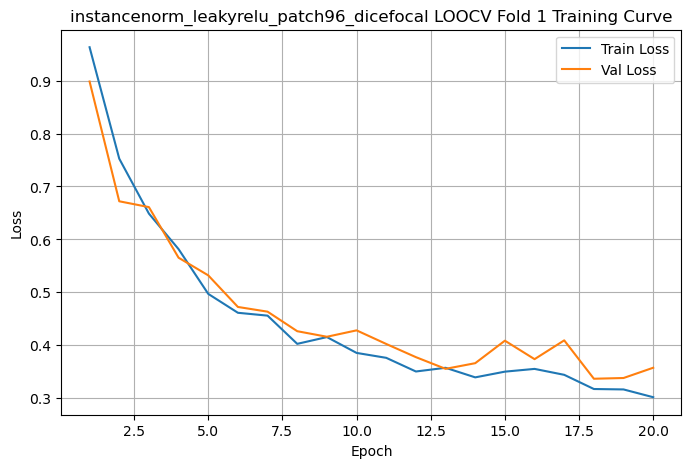

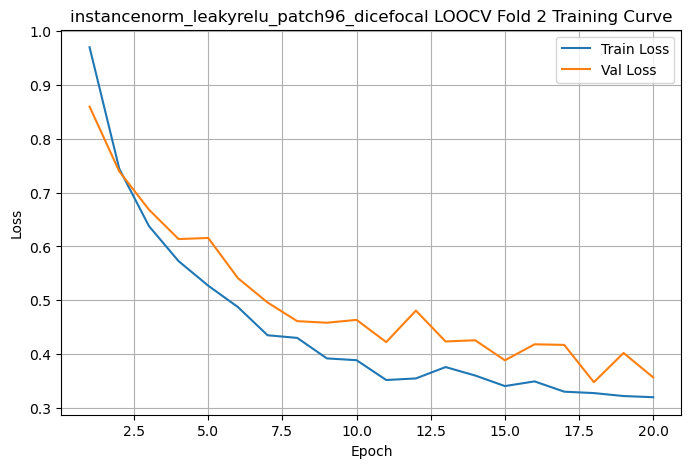

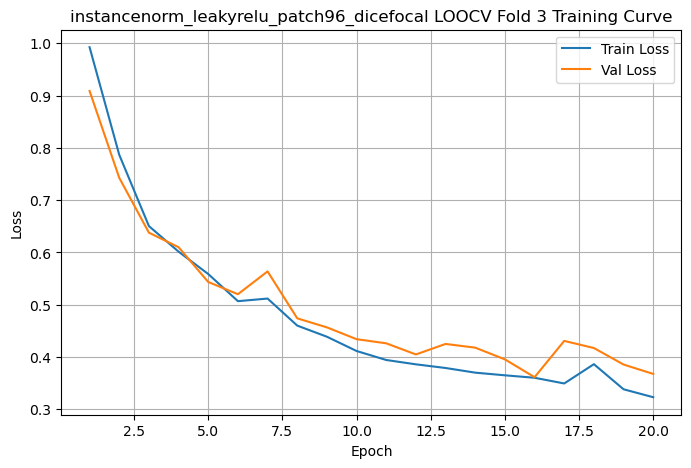

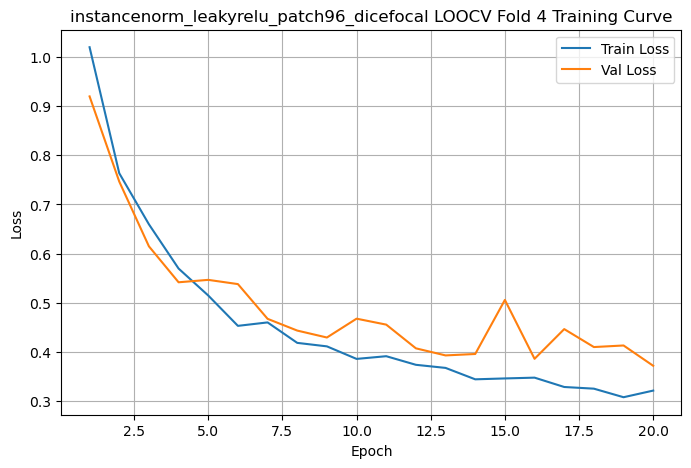

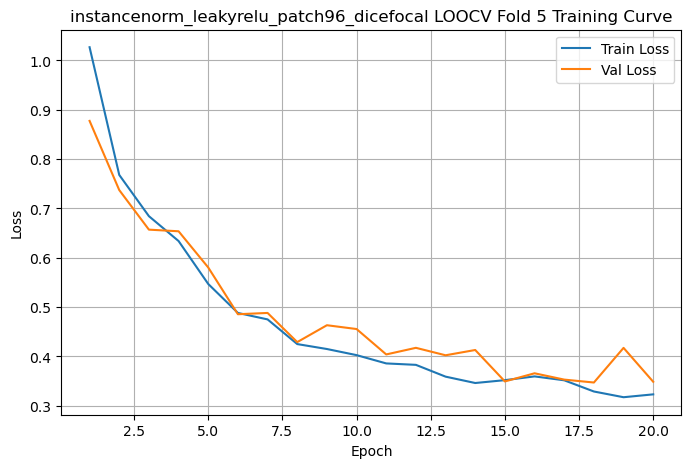

In [75]:

for fold in range(1, 6):
    log_file = f"logs/{experiment_name}_fold{fold}_log.txt"
    train_loss = []
    val_loss = []

    with open(log_file, "r") as f:
        for line in f:
            if "Train Loss" not in line:
                continue

            parts = line.strip().split("|")
            train_loss.append(float(parts[1].split(":")[1]))
            val_loss.append(float(parts[2].split(":")[1]))

    epochs = list(range(1, len(train_loss) + 1))

    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{experiment_name} LOOCV Fold {fold} Training Curve")
    plt.legend()
    plt.grid(True)

    plt.savefig(
        f"report_images/data_understanding/{experiment_name}_fold{fold}_loss_curve.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

In [76]:
import scipy.ndimage as ndimage
def get_scan_positions(image_size, patch_size, stride):
    positions = list(range(0, image_size - patch_size + 1, stride))

    last_position = image_size - patch_size

    if len(positions) == 0:
        positions = [0]
    elif positions[-1] != last_position:
        positions.append(last_position)

    return positions

def get_gaussian_map(patch_size, sigma_scale=0.125):
    """
    Creates a 3D Gaussian importance map for a patch.
    Higher values in the center, lower values near edges.
    """
    tmp = np.zeros(patch_size, dtype=np.float32)

    center = [s // 2 for s in patch_size]
    tmp[tuple(center)] = 1.0

    sigma = [s * sigma_scale for s in patch_size]

    gaussian_map = ndimage.gaussian_filter(
        tmp,
        sigma=sigma,
        mode='constant',
        cval=0
    )

    gaussian_map = gaussian_map / np.max(gaussian_map)
    gaussian_map = np.maximum(gaussian_map, 1e-8)

    return gaussian_map.astype(np.float32)


def sliding_window_inference_gaussian(
    volume,
    model,
    patch_size=(96, 96, 32),
    stride=(48, 48, 16),
    device='cuda',
    num_classes=9
):
    model.eval()

    H, W, D = volume.shape

    full_probs = np.zeros((num_classes, H, W, D), dtype=np.float32)
    weight_map = np.zeros((H, W, D), dtype=np.float32)

    importance_map = get_gaussian_map(patch_size)

    x_positions = get_scan_positions(H, patch_size[0], stride[0])
    y_positions = get_scan_positions(W, patch_size[1], stride[1])
    z_positions = get_scan_positions(D, patch_size[2], stride[2])

    for x in x_positions:
        for y in y_positions:
            for z in z_positions:

                patch = volume[
                    x:x + patch_size[0],
                    y:y + patch_size[1],
                    z:z + patch_size[2]
                ]

                patch_tensor = torch.tensor(
                    patch,
                    dtype=torch.float32
                ).unsqueeze(0).unsqueeze(0).to(device)

                with torch.no_grad():
                    logits = model(patch_tensor)
                    probs = F.softmax(logits, dim=1).cpu().numpy()[0]

                full_probs[
                    :,
                    x:x + patch_size[0],
                    y:y + patch_size[1],
                    z:z + patch_size[2]
                ] += probs * importance_map[None, :, :, :]

                weight_map[
                    x:x + patch_size[0],
                    y:y + patch_size[1],
                    z:z + patch_size[2]
                ] += importance_map

    full_probs /= np.maximum(weight_map[None, :, :, :], 1e-8)

    pred_label = np.argmax(full_probs, axis=0)

    return pred_label

In [77]:

def sliding_window_inference_safe(volume, model, patch_size=(96,96,32), stride=(48,48,16), device='cuda', num_classes=9):  # CHANGE THE PATCH SIZE AND STRIDE FOR ABLATION OTHERWISE YOU WILL GET UNFAIR ANSWERS

    model.eval()
    H, W, D = volume.shape
    full_probs = np.zeros((num_classes, H, W, D), dtype=np.float32)
    count_map = np.zeros((H, W, D), dtype=np.float32)

    # Sliding window
    for x in range(0, H-patch_size[0]+1, stride[0]):
        for y in range(0, W-patch_size[1]+1, stride[1]):
            for z in range(0, D-patch_size[2]+1, stride[2]):
                patch = volume[x:x+patch_size[0], y:y+patch_size[1], z:z+patch_size[2]]
                patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

                with torch.no_grad():
                    logits = model(patch_tensor)
                    probs = F.softmax(logits, dim=1).cpu().numpy()[0]  # [C,H,W,D]

                # Add probabilities to full volume
                full_probs[:, x:x+patch_size[0], y:y+patch_size[1], z:z+patch_size[2]] += probs
                count_map[x:x+patch_size[0], y:y+patch_size[1], z:z+patch_size[2]] += 1

    # Safe division avoid divide by zer0
    full_probs /= np.maximum(count_map[None, :, :, :], 1)

    # Final predicted labels
    pred_label = np.argmax(full_probs, axis=0)

    return pred_label

In [78]:
def dice_per_class(pred, true, num_classes=9, smooth=1e-5):
    """
    Compute Dice coefficient per class.
    """
    dice_scores = []
    for c in range(num_classes):
        pred_c = (pred == c).astype(np.float32)
        true_c = (true == c).astype(np.float32)
        intersection = np.sum(pred_c * true_c)
        union = np.sum(pred_c) + np.sum(true_c)
        dice = (2*intersection + smooth) / (union + smooth)
        dice_scores.append(dice)
    return dice_scores

In [79]:
''' The purpose of this function is to load the correct model for each LOOCV fold.
    This makes evaluation fair because each validation subject is tested using
    the model that did not train on that subject. '''

def load_fold_model(fold, device, experiment_name):
    model = UNet3D(in_channels=1, n_classes=9).to(device)

    # automatically load best model
    model_path = f"models/{experiment_name}_fold{fold}_best.pth"

    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    return model

## Class 4 inspection

Voxel counts per class:
Class 0: 2298137 voxels
Class 1: 162140 voxels
Class 2: 10350 voxels
Class 3: 105062 voxels
Class 4: 4 voxels
Class 5: 139650 voxels
Class 6: 8791 voxels
Class 7: 32940 voxels
Class 8: 7726 voxels

Total Class 4 voxels in Subject 4: 4
Best slice for Class 4: 17


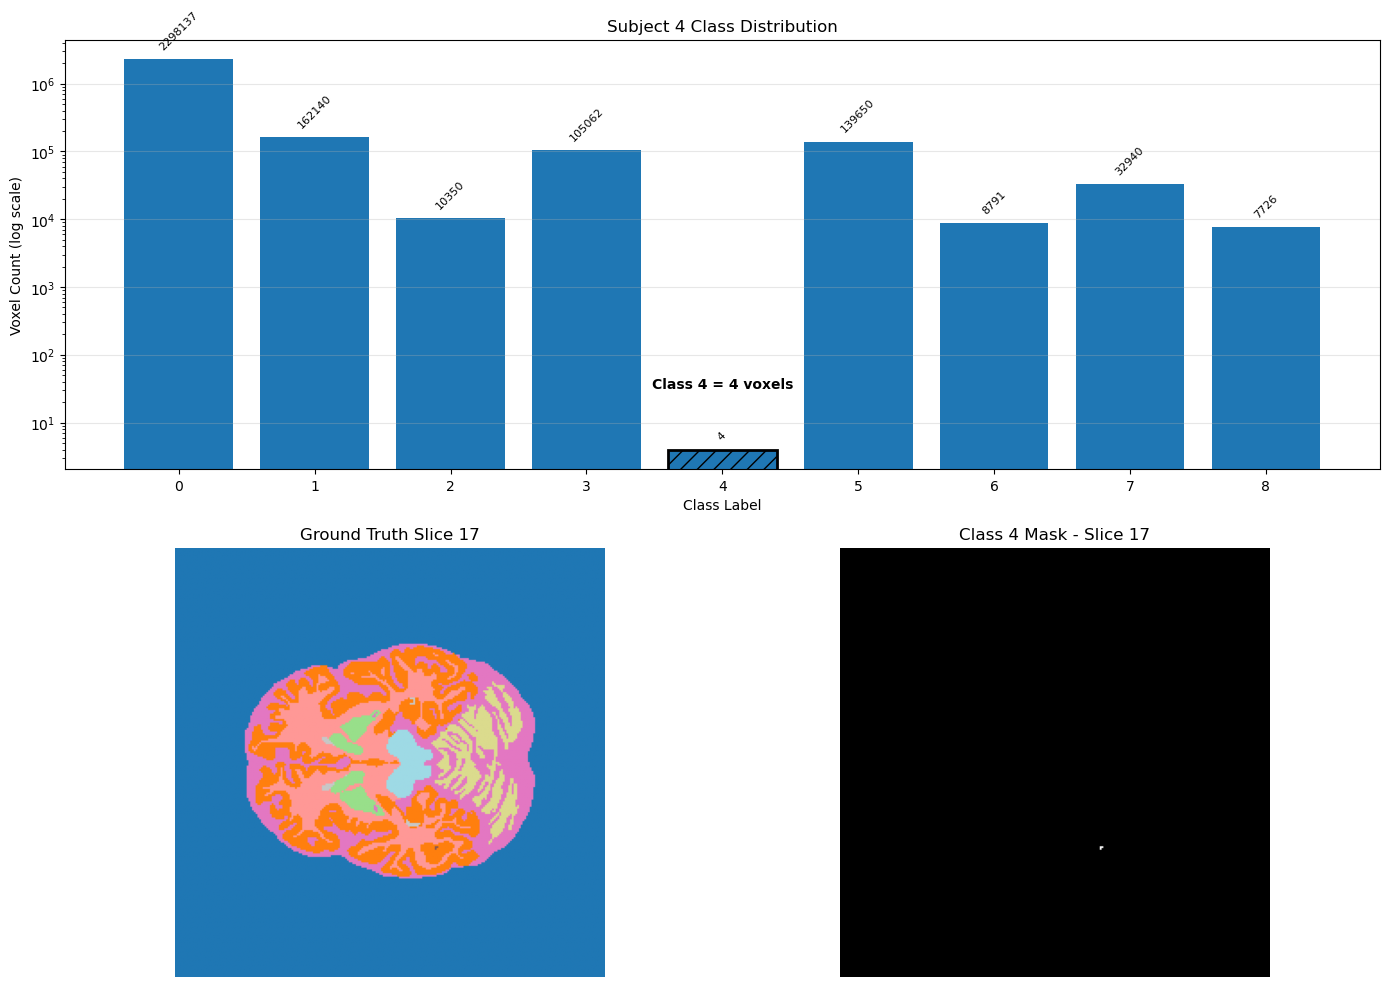

Saved: report_images/data_understanding/subject4_class4_imbalance_analysis.png


In [2]:

""" WE ARE CONTINOUSLY GETTING A DICE SCORE OF ZERO EVEN AFTER SEVERAL IMPROVEMENTS IN SUBJECT 4 
AND TO INSPECT IT WE JUST DID A QUANTITAVE ANALYSIS WHICH
SHOWS THAT IT HAS ONLY 4 VOXELS OF SUBJECT 4 WHICH ARE VERY RARE AND DIFFICULT TO DETECT """

# ============================================================
# Class imbalance inspection for Subject 4
# ============================================================

import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs("report_images/data_understanding", exist_ok=True)

label_path = 'Dataset/Extracted_Data/TrainingData/4/LabelsForTraining.nii'

# Load labels and convert to integer
gt = nib.load(label_path).get_fdata().astype(np.int32)

# Count voxels per class
unique, counts = np.unique(gt, return_counts=True)

print("Voxel counts per class:")
for u, c in zip(unique, counts):
    print(f"Class {int(u)}: {c} voxels")

# Class 4 mask
mask = (gt == 4)
class4_total = int(mask.sum())

print(f"\nTotal Class 4 voxels in Subject 4: {class4_total}")

# Best slice for Class 4
slice_idx = np.argmax(mask.sum(axis=(0, 1)))
print(f"Best slice for Class 4: {slice_idx}")

classes = unique.astype(int)

# ------------------------------------------------------------
# Plot: Histogram on top, slices below
# ------------------------------------------------------------

fig = plt.figure(figsize=(14, 10))

# Top plot: class distribution
ax1 = plt.subplot2grid((2, 2), (0, 0), colspan=2)

bars = ax1.bar(classes, counts)

# Highlight Class 4
for bar, cls in zip(bars, classes):
    if cls == 4:
        bar.set_hatch("//")
        bar.set_linewidth(2)
        bar.set_edgecolor("black")

ax1.set_yscale("log")
ax1.set_xticks(classes)
ax1.set_xlabel("Class Label")
ax1.set_ylabel("Voxel Count (log scale)")
ax1.set_title("Subject 4 Class Distribution")
ax1.grid(axis="y", alpha=0.3)

# Add voxel count labels above every bar
for cls, count in zip(classes, counts):
    ax1.text(
        cls,
        count * 1.3,
        f"{int(count)}",
        ha="center",
        va="bottom",
        fontsize=8,
        rotation=45
    )

# Extra annotation for Class 4
ax1.text(
    4,
    class4_total * 8,
    f"Class 4 = {class4_total} voxels",
    ha="center",
    fontsize=10,
    fontweight="bold"
)

# Bottom left: ground truth slice
ax2 = plt.subplot2grid((2, 2), (1, 0))
ax2.imshow(gt[:, :, slice_idx], cmap='tab20', vmin=0, vmax=8)
ax2.set_title(f"Ground Truth Slice {slice_idx}")
ax2.axis("off")

# Bottom right: Class 4 mask
ax3 = plt.subplot2grid((2, 2), (1, 1))
ax3.imshow(mask[:, :, slice_idx], cmap='gray')
ax3.set_title(f"Class 4 Mask - Slice {slice_idx}")
ax3.axis("off")

plt.tight_layout()

save_path = "report_images/data_understanding/subject4_class4_imbalance_analysis.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved: {save_path}")

## Dice Evaluation

In [81]:
os.makedirs("logs/evaluation", exist_ok=True)

all_dice = []

subjects = ['1', '2', '3', '4', '5']
num_classes = 9

eval_patch_size = (96, 96, 32)
eval_stride = (48, 48, 16)

eval_log_path = f"logs/evaluation/{experiment_name}_evaluation_log.txt"

with open(eval_log_path, "w") as f:
    f.write(f"Experiment: {experiment_name}\n")
    f.write(f"Evaluation patch size: {eval_patch_size}\n")
    f.write(f"Evaluation stride: {eval_stride}\n")
    f.write("=" * 60 + "\n\n")

for fold, subject_id in enumerate(subjects, 1):

    print(f"Processing subject {subject_id} (Fold {fold})...")

    fold_model = load_fold_model(fold, device, experiment_name)

    base_path = f'Dataset/Extracted_Data/TrainingData/{subject_id}'
    t1_path = f'{base_path}/T1.nii'
    label_path = f'{base_path}/LabelsForTraining.nii'

    # Load raw MRI
    raw_t1 = nib.load(t1_path).get_fdata()

    # Normalize MRI
    volume = normalize_volume(raw_t1)

    # Load ground truth labels
    true_label = nib.load(label_path).get_fdata().astype(np.int32)

    # Sliding-window inference
    pred_label = sliding_window_inference_gaussian(
      volume,
      fold_model,
      patch_size=eval_patch_size,
      stride=eval_stride,
      device=device,
      num_classes=num_classes)

    # Remove predictions outside brain region
    brain_mask = raw_t1 > 0
    pred_label[~brain_mask] = 0

    # Compute Dice scores
    dice_scores = dice_per_class(
        pred_label,
        true_label,
        num_classes=num_classes
    )

    all_dice.append(dice_scores)

    dice_text = ["{:.3f}".format(d) for d in dice_scores]

    print("Dice per class:", dice_text)

    with open(eval_log_path, "a") as f:
        f.write(f"Subject {subject_id} | Fold {fold}\n")
        f.write(f"Dice per class: {dice_text}\n")
        f.write("\n")

# Convert to numpy array
all_dice = np.array(all_dice)

# Average Dice per class
avg_dice = np.mean(all_dice, axis=0)

# Mean Dice
mean_dice_including_background = np.mean(avg_dice)
mean_dice_excluding_background = np.mean(avg_dice[1:])

print("\nClass | Avg Dice")
for i, d in enumerate(avg_dice):
    print(f"{i}     | {d:.3f}")

print(f"\nMean Dice including background: {mean_dice_including_background:.3f}")
print(f"Mean Dice excluding background: {mean_dice_excluding_background:.3f}")

# Save final summary
with open(eval_log_path, "a") as f:

    f.write("=" * 60 + "\n")
    f.write("Average Dice per class\n")

    for i, d in enumerate(avg_dice):
        f.write(f"Class {i}: {d:.3f}\n")

    f.write("\n")
    f.write(f"Mean Dice including background: {mean_dice_including_background:.3f}\n")
    f.write(f"Mean Dice excluding background: {mean_dice_excluding_background:.3f}\n")

print(f"\nSaved evaluation log: {eval_log_path}")

Processing subject 1 (Fold 1)...
Dice per class: ['0.993', '0.821', '0.799', '0.886', '0.311', '0.766', '0.956', '0.894', '0.908']
Processing subject 2 (Fold 2)...
Dice per class: ['0.992', '0.831', '0.803', '0.826', '0.528', '0.760', '0.930', '0.872', '0.891']
Processing subject 3 (Fold 3)...
Dice per class: ['0.992', '0.824', '0.759', '0.865', '0.430', '0.750', '0.903', '0.881', '0.919']
Processing subject 4 (Fold 4)...
Dice per class: ['0.991', '0.838', '0.810', '0.856', '0.000', '0.761', '0.907', '0.898', '0.891']
Processing subject 5 (Fold 5)...
Dice per class: ['0.989', '0.862', '0.753', '0.898', '0.374', '0.718', '0.924', '0.878', '0.917']

Class | Avg Dice
0     | 0.991
1     | 0.835
2     | 0.785
3     | 0.866
4     | 0.329
5     | 0.751
6     | 0.924
7     | 0.885
8     | 0.905

Mean Dice including background: 0.808
Mean Dice excluding background: 0.785

Saved evaluation log: logs/evaluation/instancenorm_leakyrelu_patch96_dicefocal_evaluation_log.txt


In [82]:
import pandas as pd
# NO OF PATCHES FOR EACH EPOCH 
patch_ablation_results = [
    {
        "experiment": "dicece03_patch50",
        "patches_per_epoch": 50,
        "mean_dice": 0.557,
        "training_time_min": 2.19,
        "peak_gpu_memory_mb": 329.99,
        "best_epoch_avg": 18.8
    },
    {
        "experiment": "dicece03_patch100",
        "patches_per_epoch": 100,
        "mean_dice": 0.642,
        "training_time_min": 3.74,
        "peak_gpu_memory_mb": 345.21,
        "best_epoch_avg": 15.6
    },
    {
        "experiment": "dicece03_patch150",
        "patches_per_epoch": 150,
        "mean_dice": 0.732,
        "training_time_min": 5.21,
        "peak_gpu_memory_mb": 333.01,
        "best_epoch_avg": 17.2
    }
]

df = pd.DataFrame(patch_ablation_results)
df

,experiment,patches_per_epoch,mean_dice,training_time_min,peak_gpu_memory_mb,best_epoch_avg
0,dicece03_patch50,50,0.557,2.19,329.99,18.8
1,dicece03_patch100,100,0.642,3.74,345.21,15.6
2,dicece03_patch150,150,0.732,5.21,333.01,17.2


In [83]:
import pandas as pd

patch_size_results = [
    {
        "experiment": "dicece03_patchsize64",
        "patch_size": "(64,64,32)",
        "inference_stride": "(32,32,16)",
        "mean_dice": 0.642,
        "class4_dice": 0.233,
        "training_time_min": 3.74,
        "peak_gpu_memory_mb": 345.21,
        "best_epoch_avg": 15.6
    },
    {
        "experiment": "dicece03_patchsize80",
        "patch_size": "(80,80,32)",
        "inference_stride": "(40,40,16)",
        "mean_dice": 0.776,
        "class4_dice": 0.234,
        "training_time_min": 3.51,
        "peak_gpu_memory_mb": 489.11,
        "best_epoch_avg": 16.4
    },
    {
        "experiment": "dicece03_patchsize96",
        "patch_size": "(96,96,32)",
        "inference_stride": "(48,48,16)",
        "mean_dice": 0.803,
        "class4_dice": 0.259,
        "training_time_min": 3.46,
        "peak_gpu_memory_mb": 658.49,
        "best_epoch_avg": 18.0
    }
]

df_patch_size = pd.DataFrame(patch_size_results)
df_patch_size

,experiment,patch_size,inference_stride,mean_dice,class4_dice,training_time_min,peak_gpu_memory_mb,best_epoch_avg
0,dicece03_patchsize64,"(64,64,32)","(32,32,16)",0.642,0.233,3.74,345.21,15.6
1,dicece03_patchsize80,"(80,80,32)","(40,40,16)",0.776,0.234,3.51,489.11,16.4
2,dicece03_patchsize96,"(96,96,32)","(48,48,16)",0.803,0.259,3.46,658.49,18.0


In [84]:
def get_best_slice(label_volume):
    """
    Find slice with maximum foreground 
    """
    max_pixels = 0
    best_idx = 0

    for i in range(label_volume.shape[2]):
        slice_data = label_volume[:, :, i]
        foreground_pixels = np.sum(slice_data > 0)

        if foreground_pixels > max_pixels:
            max_pixels = foreground_pixels
            best_idx = i

    return best_idx

In [85]:



def visualize_single_slice(subject_id, model, device, experiment_name):
    base_path = f'Dataset/Extracted_Data/TrainingData/{subject_id}'
    
    t1 = nib.load(f'{base_path}/T1.nii').get_fdata()
    gt = nib.load(f'{base_path}/LabelsForTraining.nii').get_fdata().astype(np.int32)
    
    volume = normalize_volume(t1)

    pred = sliding_window_inference_gaussian(
        volume,
        model,
        patch_size=(96,96,32),
        stride=(48,48,16),
        device=device,
        num_classes=9)
    
    # remove predictions outside the brain
    brain_mask = t1 > 0
    pred[~brain_mask] = 0

    # get best slice 
    idx = get_best_slice(gt)

    plt.figure(figsize=(10,4))

    # T1 MRI
    plt.subplot(1,3,1)
    plt.imshow(volume[:,:,idx], cmap='gray')
    plt.title(f"T1 MRI (Slice {idx})")
    plt.axis('off')

    # Ground truth
    plt.subplot(1,3,2)
    plt.imshow(gt[:,:,idx], cmap='tab10', vmin=0, vmax=8)
    plt.title("Ground Truth")
    plt.axis('off')

    # Prediction
    plt.subplot(1,3,3)
    plt.imshow(pred[:,:,idx], cmap='tab10', vmin=0, vmax=8)
    plt.title("Prediction")
    plt.axis('off')

    plt.tight_layout()

    save_path = f"report_images/qualitative/{experiment_name}_gaussian_subject_{subject_id}_best_slice.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"Saved: {save_path}")

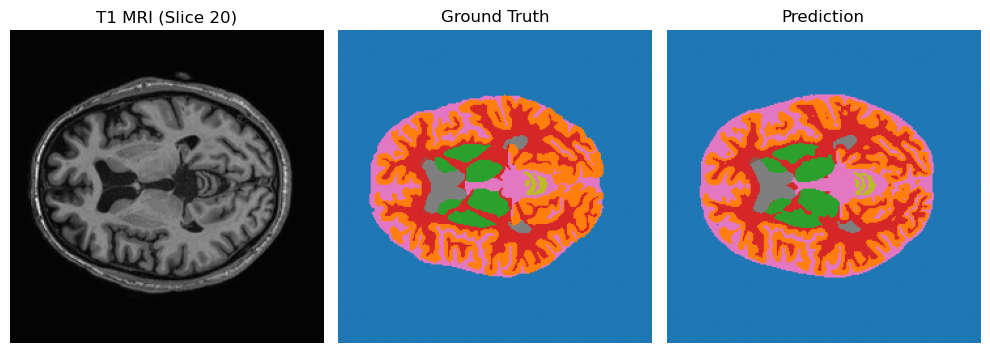

Saved: report_images/qualitative/final_fullsystem_softweightedce_gaussian_subject_1_best_slice.png


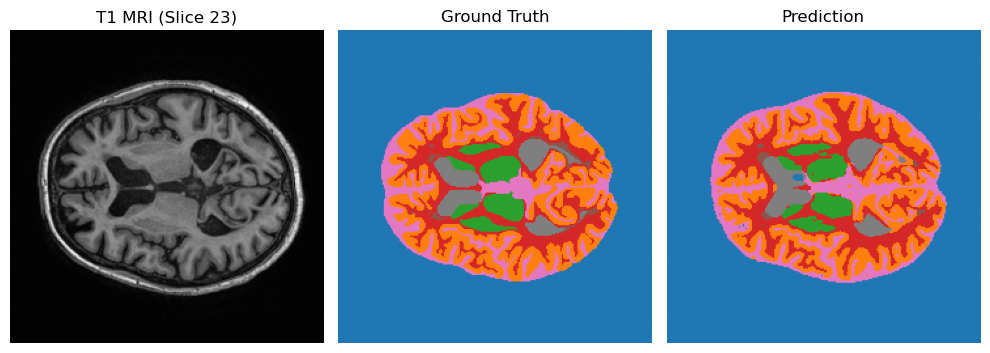

Saved: report_images/qualitative/final_fullsystem_softweightedce_gaussian_subject_2_best_slice.png


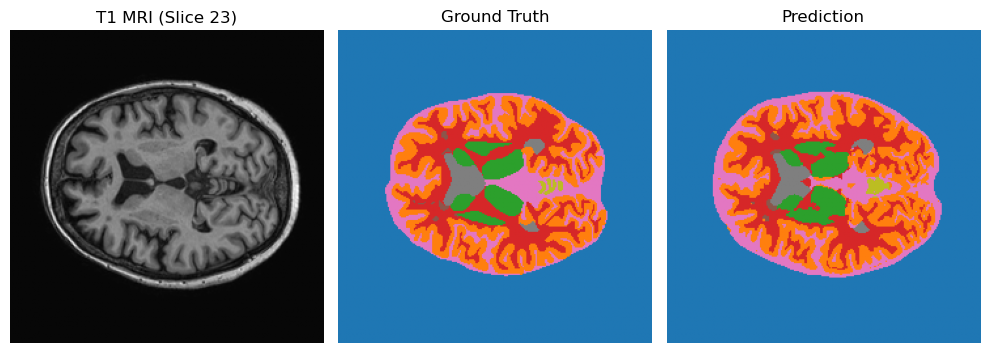

Saved: report_images/qualitative/final_fullsystem_softweightedce_gaussian_subject_3_best_slice.png


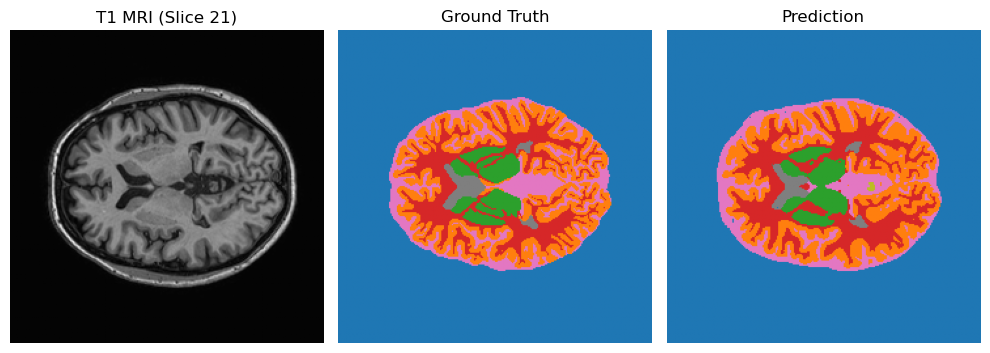

Saved: report_images/qualitative/final_fullsystem_softweightedce_gaussian_subject_4_best_slice.png


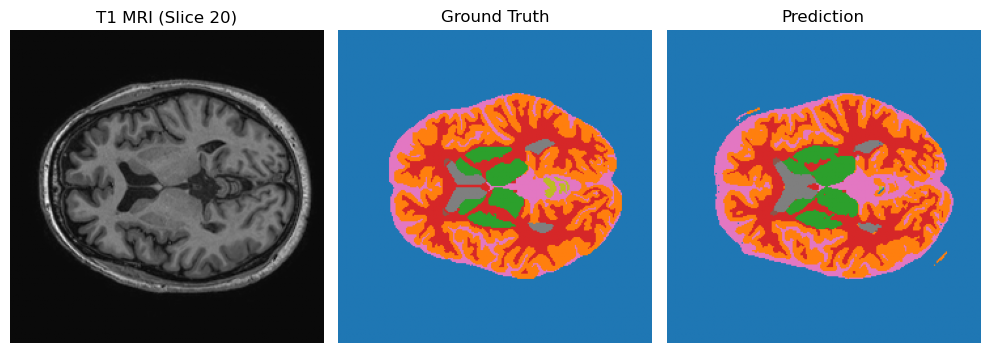

Saved: report_images/qualitative/final_fullsystem_softweightedce_gaussian_subject_5_best_slice.png


In [65]:
subjects = ['1', '2', '3', '4', '5']

for fold, subject_id in enumerate(subjects, 1):
     #  fold_model = load_fold_model(fold, device, experiment_name="baseline")
    fold_model = load_fold_model(fold, device, experiment_name)
    visualize_single_slice(subject_id, fold_model, device, experiment_name)